# Herramientas y visualización de datos - Actividad práctica final
## Visualización de grandes volúmenes de datos con Apache Spark

**Dataset:** MovieLens 32M + MovieLens Latest  
**Tema:** Análisis de calificaciones de películas mediante Spark  
**Integrantes:** Diego Bueno / JuanFer  
**Fecha:** 2026

## 1. Introducción

Se seleccionó MovieLens porque contiene millones de calificaciones reales de películas realizadas por usuarios. El dataset permite aplicar Apache Spark para cargar, limpiar, transformar y visualizar grandes volúmenes de datos.

El análisis responde preguntas sobre distribución de calificaciones, películas más populares, evolución temporal y relación entre popularidad y calificación promedio.

In [27]:
 !pip install pyspark pandas matplotlib seaborn plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Configuración inicial de Spark

In [28]:
import os
import sys
import tempfile
from pathlib import Path

if sys.platform.startswith('win'):
    hadoop_home = os.path.join(tempfile.gettempdir(), 'hadoop')
    os.makedirs(os.path.join(hadoop_home, 'bin'), exist_ok=True)
    os.environ['HADOOP_HOME'] = hadoop_home

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName("MovieLens Big Data Visualization")
    .master("local[2]")
    .config("spark.driver.memory", "3g")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

print("Spark iniciado correctamente")

Spark iniciado correctamente


## 3. Rutas del dataset

In [29]:
ruta_base = Path(r"C:\Users\JuanFer\Documents\Actividad 3")

ml32_path = ruta_base / "ml-32m" / "ml-32m"
mllatest_path = ruta_base / "ml-latest" / "ml-latest"

print("Existe ml-latest:", mllatest_path.exists())

print("Archivos ml-latest:")
print(list(mllatest_path.glob("*")))

Existe ml-latest: True
Archivos ml-latest:
[WindowsPath('C:/Users/JuanFer/Documents/Actividad 3/ml-latest/ml-latest/genome-scores.csv'), WindowsPath('C:/Users/JuanFer/Documents/Actividad 3/ml-latest/ml-latest/genome-tags.csv'), WindowsPath('C:/Users/JuanFer/Documents/Actividad 3/ml-latest/ml-latest/links.csv'), WindowsPath('C:/Users/JuanFer/Documents/Actividad 3/ml-latest/ml-latest/movies.csv'), WindowsPath('C:/Users/JuanFer/Documents/Actividad 3/ml-latest/ml-latest/ratings.csv'), WindowsPath('C:/Users/JuanFer/Documents/Actividad 3/ml-latest/ml-latest/tags.csv')]


## 4. Verificación del tamaño del dataset

In [30]:
import os

archivos_dataset = []
for carpeta in [ml32_path, mllatest_path]:
    if carpeta.exists():
        archivos_dataset.extend(list(carpeta.glob("*.csv")))

total_gb = 0
for archivo in archivos_dataset:
    size_gb = os.path.getsize(archivo) / (1024 ** 3)
    total_gb += size_gb
    print(f"{archivo.name}: {size_gb:.2f} GB")

print(f"\nTamaño total aproximado del dataset usado: {total_gb:.2f} GB")

if total_gb >= 1:
    print("El dataset cumple el requisito mínimo de 1 GB.")
else:
    print("Advertencia: el dataset no alcanza 1 GB. Verifica que estén las carpetas completas.")

genome-scores.csv: 0.49 GB
genome-tags.csv: 0.00 GB
links.csv: 0.00 GB
movies.csv: 0.00 GB
ratings.csv: 0.87 GB
tags.csv: 0.08 GB

Tamaño total aproximado del dataset usado: 1.44 GB
El dataset cumple el requisito mínimo de 1 GB.


## 5. Carga del dataset con Spark

In [31]:
ratings_path = mllatest_path / "ratings.csv"
movies_path = mllatest_path / "movies.csv"
tags_path = mllatest_path / "tags.csv"

ratings = spark.read.csv(
    str(ratings_path),
    header=True,
    inferSchema=True
)

movies = spark.read.csv(
    str(movies_path),
    header=True,
    inferSchema=True
)

# tags.csv se carga solo si existe, para evitar errores en equipos donde no esté disponible.
if tags_path.exists():
    tags = spark.read.csv(
        str(tags_path),
        header=True,
        inferSchema=True
    )
else:
    tags = None

print("Ratings:")
ratings.limit(5).show()

print("Movies:")
movies.limit(5).show(truncate=False)

if tags is not None:
    print("Tags:")
    tags.limit(5).show(truncate=False)
else:
    print("No se encontró tags.csv. El análisis continuará con ratings y movies.")


Ratings:
+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|      1|   4.0|1225734739|
|     1|    110|   4.0|1225865086|
|     1|    158|   4.0|1225733503|
|     1|    260|   4.5|1225735204|
|     1|    356|   5.0|1225735119|
+------+-------+------+----------+

Movies:
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|

## 6. Conteo de registros

In [33]:
total_ratings = ratings.count()
total_movies = movies.count()
total_tags = tags.count() if tags is not None else 0

print(f"Total de registros en ratings: {total_ratings:,}")
print(f"Total de registros en movies: {total_movies:,}")
print(f"Total de registros en tags: {total_tags:,}")


Total de registros en ratings: 33,832,162
Total de registros en movies: 86,537
Total de registros en tags: 2,000,072


## 7. Exploración inicial y limpieza

In [ ]:
nulls_ratings = ratings.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ratings.columns
])

print("Valores nulos en ratings:")
nulls_ratings.show()

nulls_movies = movies.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in movies.columns
])

print("Valores nulos en movies:")
nulls_movies.show()

duplicados_ratings = ratings.count() - ratings.dropDuplicates().count()
duplicados_movies = movies.count() - movies.dropDuplicates().count()

print(f"Duplicados en ratings: {duplicados_ratings:,}")
print(f"Duplicados en movies: {duplicados_movies:,}")

ratings.select(
    F.min("rating").alias("rating_minimo"),
    F.max("rating").alias("rating_maximo"),
    F.avg("rating").alias("rating_promedio")
).show()

Valores nulos en ratings:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

Valores nulos en movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

Duplicados en ratings: 0
Duplicados en movies: 0
+-------------+-------------+------------------+
|rating_minimo|rating_maximo|   rating_promedio|
+-------------+-------------+------------------+
|          0.5|          5.0|3.5403956487277393|
+-------------+-------------+------------------+



### Decisiones de limpieza

Se eliminan duplicados, registros nulos en columnas clave, calificaciones fuera del rango válido y se transforma el `timestamp` a fecha para análisis temporal.

In [ ]:
ratings_clean = (
    ratings
    .dropDuplicates()
    .filter(F.col("userId").isNotNull())
    .filter(F.col("movieId").isNotNull())
    .filter(F.col("rating").isNotNull())
    .filter(F.col("timestamp").isNotNull())
    .filter((F.col("rating") >= 0.5) & (F.col("rating") <= 5.0))
    .withColumn("fecha", F.to_date(F.from_unixtime(F.col("timestamp"))))
    .withColumn("anio", F.year(F.col("fecha")))
)

movies_clean = (
    movies
    .dropDuplicates()
    .filter(F.col("movieId").isNotNull())
    .filter(F.col("title").isNotNull())
    .filter(F.col("genres").isNotNull())
)

ratings_clean.cache()
movies_clean.cache()

print(f"Registros limpios en ratings: {ratings_clean.count():,}")
print(f"Registros limpios en movies: {movies_clean.count():,}")
ratings_clean.limit(5).show()

Registros limpios en ratings: 32,000,204
Registros limpios en movies: 87,585
+------+-------+------+---------+----------+----+
|userId|movieId|rating|timestamp|     fecha|anio|
+------+-------+------+---------+----------+----+
|     1|     25|   1.0|944250228|1999-12-03|1999|
|     1|     32|   5.0|943228858|1999-11-21|1999|
|     1|    110|   3.0|943231119|1999-11-21|1999|
|     1|    176|   4.0|944079496|1999-12-01|1999|
|     1|    322|   4.0|944053801|1999-12-01|1999|
+------+-------+------+---------+----------+----+



## 8. Integración de datos

In [ ]:
ratings_movies = ratings_clean.join(movies_clean, on="movieId", how="inner")
ratings_movies.limit(5).show(truncate=False)

+-------+------+------+---------+----------+----+-----------------------------------------+-----------------------+
|movieId|userId|rating|timestamp|fecha     |anio|title                                    |genres                 |
+-------+------+------+---------+----------+----+-----------------------------------------+-----------------------+
|25     |1     |1.0   |944250228|1999-12-03|1999|Leaving Las Vegas (1995)                 |Drama|Romance          |
|32     |1     |5.0   |943228858|1999-11-21|1999|Twelve Monkeys (a.k.a. 12 Monkeys) (1995)|Mystery|Sci-Fi|Thriller|
|110    |1     |3.0   |943231119|1999-11-21|1999|Braveheart (1995)                        |Action|Drama|War       |
|176    |1     |4.0   |944079496|1999-12-01|1999|Living in Oblivion (1995)                |Comedy                 |
|322    |1     |4.0   |944053801|1999-12-01|1999|Swimming with Sharks (1995)              |Comedy|Drama           |
+-------+------+------+---------+----------+----+-----------------------

## Visualización 1: Distribución de calificaciones

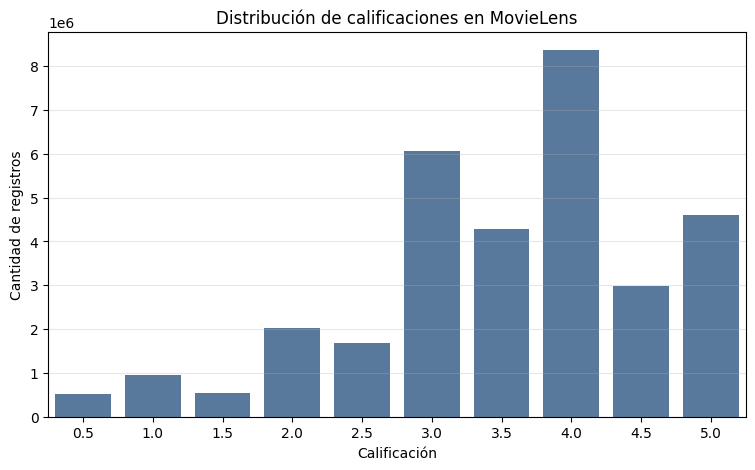

In [ ]:
rating_distribution = (
    ratings_clean
    .groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)

plt.figure(figsize=(9,5))
sns.barplot(data=rating_distribution, x="rating", y="count", color="#4C78A8")
plt.title("Distribución de calificaciones en MovieLens")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de registros")
plt.grid(axis="y", alpha=0.3)
plt.show()

**Interpretación:** La distribución muestra cuáles calificaciones son más frecuentes y permite observar la tendencia general de los usuarios al valorar películas.

## Visualización 2: Películas con mayor número de calificaciones

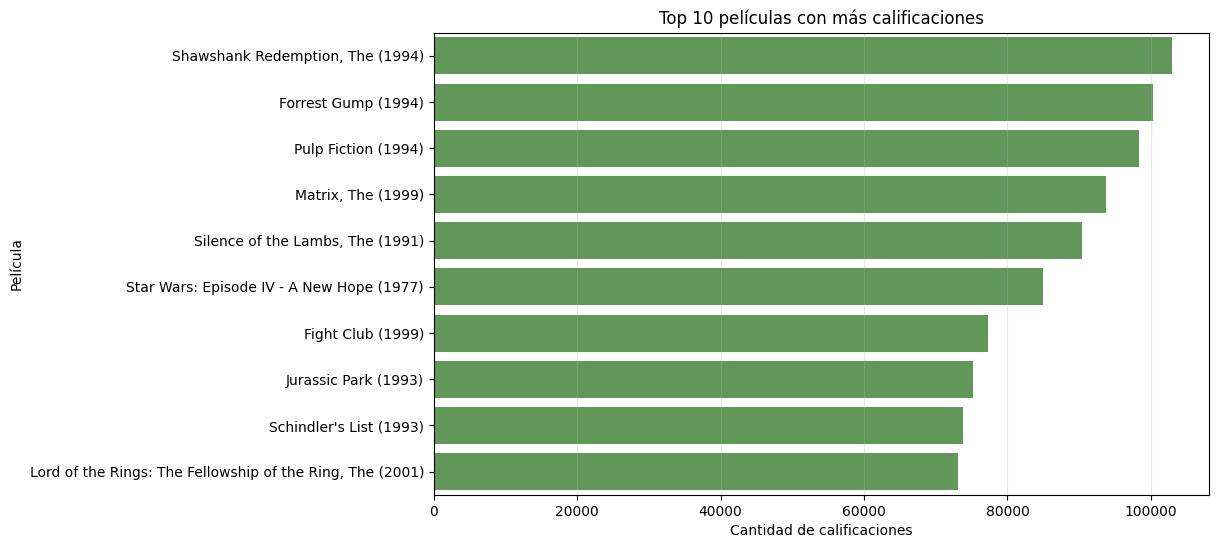

In [ ]:
top_movies = (
    ratings_movies
    .groupBy("title")
    .agg(F.count("rating").alias("cantidad_calificaciones"))
    .orderBy(F.desc("cantidad_calificaciones"))
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_movies, y="title", x="cantidad_calificaciones", color="#59A14F")
plt.title("Top 10 películas con más calificaciones")
plt.xlabel("Cantidad de calificaciones")
plt.ylabel("Película")
plt.grid(axis="x", alpha=0.3)
plt.show()

**Interpretación:** Las películas con más calificaciones representan los títulos de mayor popularidad dentro del dataset.

## Visualización 3: Evolución de calificaciones por año

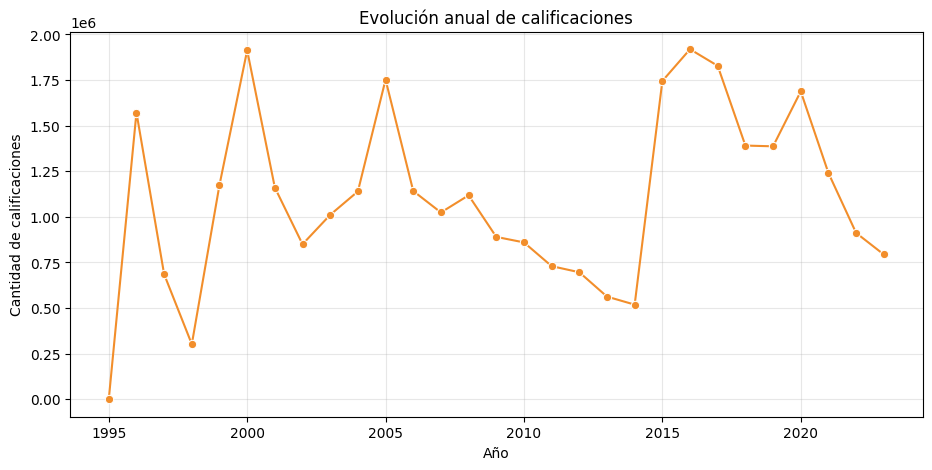

In [ ]:
ratings_by_year = (
    ratings_clean
    .filter(F.col("anio").isNotNull())
    .groupBy("anio")
    .count()
    .orderBy("anio")
    .toPandas()
)

plt.figure(figsize=(11,5))
sns.lineplot(data=ratings_by_year, x="anio", y="count", marker="o", color="#F28E2B")
plt.title("Evolución anual de calificaciones")
plt.xlabel("Año")
plt.ylabel("Cantidad de calificaciones")
plt.grid(alpha=0.3)
plt.show()

**Interpretación:** La tendencia temporal permite identificar periodos de mayor o menor actividad de los usuarios.

## Visualización 4: Popularidad vs calificación promedio

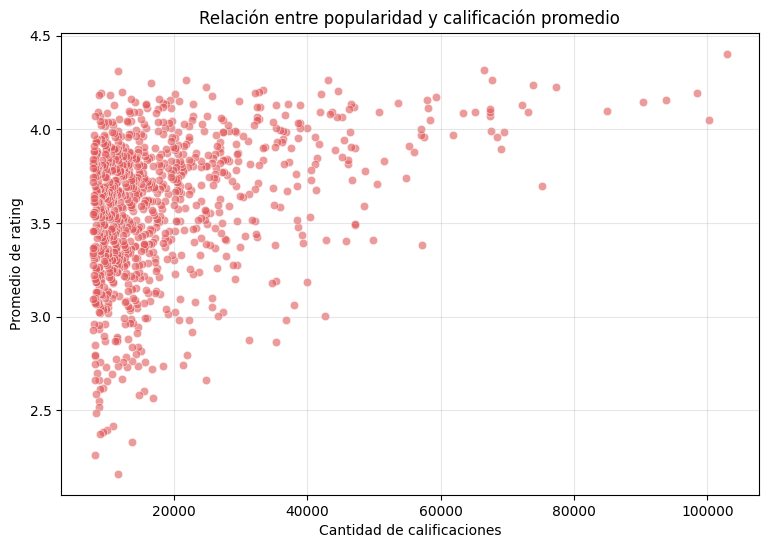

In [ ]:
movie_stats = (
    ratings_movies
    .groupBy("title")
    .agg(
        F.count("rating").alias("cantidad_calificaciones"),
        F.avg("rating").alias("promedio_rating")
    )
    .filter(F.col("cantidad_calificaciones") >= 500)
    .orderBy(F.desc("cantidad_calificaciones"))
    .limit(1000)
    .toPandas()
)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=movie_stats,
    x="cantidad_calificaciones",
    y="promedio_rating",
    alpha=0.6,
    color="#E15759"
)
plt.title("Relación entre popularidad y calificación promedio")
plt.xlabel("Cantidad de calificaciones")
plt.ylabel("Promedio de rating")
plt.grid(alpha=0.3)
plt.show()

**Interpretación:** La visualización permite analizar si las películas más populares también tienen mejores promedios de calificación.

## Visualización 5: Mapa de calor de calificaciones por año

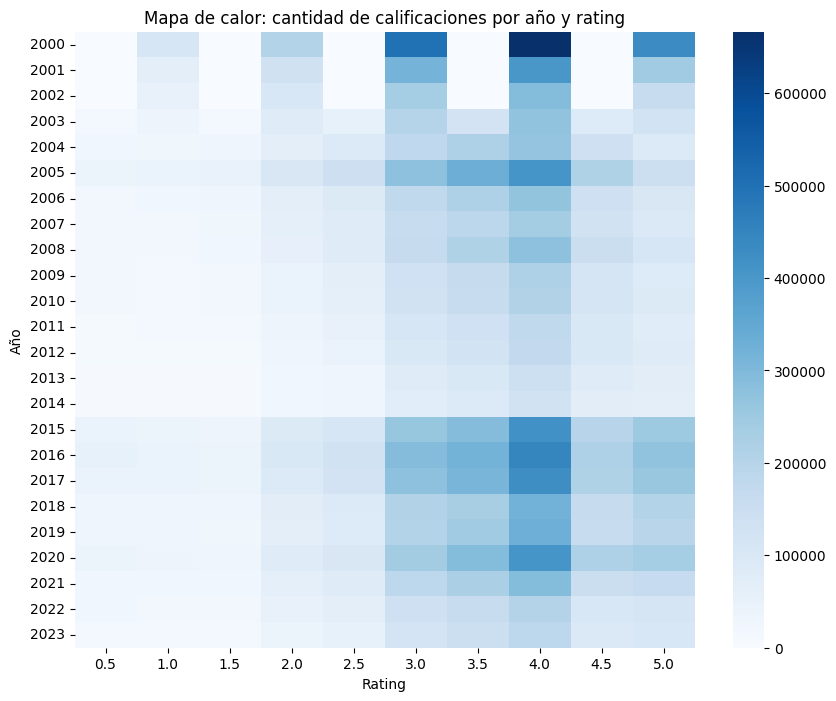

In [ ]:
heatmap_data = (
    ratings_clean
    .filter(F.col("anio").isNotNull())
    .groupBy("anio", "rating")
    .count()
    .orderBy("anio", "rating")
    .toPandas()
)

heatmap_data = heatmap_data[heatmap_data["anio"] >= 2000]

pivot_heatmap = heatmap_data.pivot_table(
    index="anio",
    columns="rating",
    values="count",
    fill_value=0
)

plt.figure(figsize=(10,8))
sns.heatmap(pivot_heatmap, cmap="Blues")
plt.title("Mapa de calor: cantidad de calificaciones por año y rating")
plt.xlabel("Rating")
plt.ylabel("Año")
plt.show()

**Interpretación:** El mapa de calor permite observar la concentración de calificaciones por año y por valor de rating.

## 9. Comparación de rendimiento: Spark DataFrame API vs Spark SQL

Para evidenciar la diferencia de demora entre el procesamiento usado anteriormente con Spark DataFrame API y el uso de Spark SQL, se ejecutan las mismas consultas con ambos enfoques.  

La comparación se realiza midiendo el tiempo con `time.perf_counter()` y forzando la ejecución con acciones como `.count()` o `.collect()`, porque Spark trabaja con evaluación perezosa: si no se ejecuta una acción, realmente no se procesa la consulta.


In [ ]:
import time

# Se crean vistas temporales para poder consultar los DataFrames con SQL Spark.
ratings_clean.createOrReplaceTempView("ratings_clean")
movies_clean.createOrReplaceTempView("movies_clean")
ratings_movies.createOrReplaceTempView("ratings_movies")

resultados_tiempos = []

def medir_tiempo(nombre, metodo, funcion):
    """Ejecuta una consulta Spark, fuerza la acción y registra el tiempo."""
    inicio = time.perf_counter()
    resultado = funcion()
    fin = time.perf_counter()
    demora = fin - inicio
    resultados_tiempos.append({
        "consulta": nombre,
        "metodo": metodo,
        "tiempo_segundos": demora
    })
    print(f"{nombre} | {metodo}: {demora:.4f} segundos")
    return resultado

# 1. Distribución de calificaciones
medir_tiempo(
    "Distribución de calificaciones",
    "DataFrame API",
    lambda: ratings_clean.groupBy("rating").count().orderBy("rating").collect()
)

medir_tiempo(
    "Distribución de calificaciones",
    "Spark SQL",
    lambda: spark.sql("""
        SELECT rating, COUNT(*) AS count
        FROM ratings_clean
        GROUP BY rating
        ORDER BY rating
    """).collect()
)

# 2. Top 10 películas con más calificaciones
medir_tiempo(
    "Top 10 películas populares",
    "DataFrame API",
    lambda: ratings_movies
        .groupBy("title")
        .agg(F.count("rating").alias("cantidad_calificaciones"))
        .orderBy(F.desc("cantidad_calificaciones"))
        .limit(10)
        .collect()
)

medir_tiempo(
    "Top 10 películas populares",
    "Spark SQL",
    lambda: spark.sql("""
        SELECT title, COUNT(rating) AS cantidad_calificaciones
        FROM ratings_movies
        GROUP BY title
        ORDER BY cantidad_calificaciones DESC
        LIMIT 10
    """).collect()
)

# 3. Evolución anual de calificaciones
medir_tiempo(
    "Evolución anual de calificaciones",
    "DataFrame API",
    lambda: ratings_clean
        .filter(F.col("anio").isNotNull())
        .groupBy("anio")
        .count()
        .orderBy("anio")
        .collect()
)

medir_tiempo(
    "Evolución anual de calificaciones",
    "Spark SQL",
    lambda: spark.sql("""
        SELECT anio, COUNT(*) AS count
        FROM ratings_clean
        WHERE anio IS NOT NULL
        GROUP BY anio
        ORDER BY anio
    """).collect()
)

# 4. Popularidad vs promedio de rating
medir_tiempo(
    "Popularidad vs promedio rating",
    "DataFrame API",
    lambda: ratings_movies
        .groupBy("title")
        .agg(
            F.count("rating").alias("cantidad_calificaciones"),
            F.avg("rating").alias("promedio_rating")
        )
        .filter(F.col("cantidad_calificaciones") >= 500)
        .orderBy(F.desc("cantidad_calificaciones"))
        .limit(1000)
        .collect()
)

medir_tiempo(
    "Popularidad vs promedio rating",
    "Spark SQL",
    lambda: spark.sql("""
        SELECT
            title,
            COUNT(rating) AS cantidad_calificaciones,
            AVG(rating) AS promedio_rating
        FROM ratings_movies
        GROUP BY title
        HAVING cantidad_calificaciones >= 500
        ORDER BY cantidad_calificaciones DESC
        LIMIT 1000
    """).collect()
)

tiempos_df = pd.DataFrame(resultados_tiempos)
tiempos_df


### Visualización comparativa de tiempos

La siguiente gráfica permite observar cuál método tarda menos en cada consulta. En algunos casos Spark SQL puede ser similar o ligeramente más rápido porque Spark usa el optimizador Catalyst para planificar la consulta. Sin embargo, la diferencia real depende del equipo, la memoria disponible, el tamaño del dataset y si los datos están en caché.


In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=tiempos_df,
    x="consulta",
    y="tiempo_segundos",
    hue="metodo"
)
plt.title("Comparación de demora: Spark DataFrame API vs Spark SQL")
plt.xlabel("Consulta ejecutada")
plt.ylabel("Tiempo de ejecución en segundos")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()


### Conclusión de la comparación

La comparación muestra que Spark DataFrame API y Spark SQL ejecutan operaciones equivalentes sobre los mismos datos. La ventaja de Spark SQL es que permite escribir consultas con una sintaxis más cercana a bases de datos tradicionales, mientras que DataFrame API resulta útil para construir transformaciones programáticas en Python.

En términos de rendimiento, ambos métodos pueden tener tiempos parecidos porque internamente Spark optimiza los planes de ejecución. Por esta razón, la mejor elección no depende únicamente de la demora, sino también de la claridad, facilidad de mantenimiento y tipo de análisis que se desea realizar.


## 10. Conclusiones

Apache Spark permitió cargar y procesar un dataset de gran volumen sin convertir directamente todos los datos a Pandas.  
Los hallazgos muestran la distribución de calificaciones, las películas más populares, la evolución temporal de la actividad y la relación entre popularidad y promedio de rating.

### Limitaciones

El rendimiento depende del equipo local. Por eso, todas las agregaciones pesadas se hacen con Spark y solo los resultados reducidos se convierten a Pandas.

## 11. Cierre de Spark

In [ ]:
spark.stop()
print("Sesión Spark cerrada correctamente")

Sesión Spark cerrada correctamente
